# Week 3 Homework — Mall Customer Segmentation

**Worked solution.** Every number in the written answers is produced by the cell above it.

Dataset: 200 mall customers, with age, annual income (k$) and a 1-100 spending score.
Two unsupervised methods, K-Means and DBSCAN, and a comparison.

Reproducibility: `random_state=42`, `init='k-means++'`, `n_init=10` throughout.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score

import warnings
warnings.filterwarnings('ignore', message='.*n_init.*')

pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 30)

import sklearn
print('scikit-learn', sklearn.__version__)

RANDOM_STATE = 42
INCOME = 'Annual Income (k$)'
SPEND = 'Spending Score (1-100)'

scikit-learn 1.9.1


# Part 1: Exploration & Preprocessing

In [2]:
URL = ('https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/'
       'Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/'
       'Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv')

df = pd.read_csv(URL).drop(columns=['CustomerID'])

print(df.head())
print()
df.info()
print()
print(df.describe().round(2).to_string())

    Genre  Age  Annual Income (k$)  Spending Score (1-100)
0    Male   19                  15                      39
1    Male   21                  15                      81
2  Female   20                  16                       6
3  Female   23                  16                      77
4  Female   31                  17                      40

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Genre                   200 non-null    str  
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(3), str(1)
memory usage: 6.4 KB

          Age  Annual Income (k$)  Spending Score (1-100)
count  200.00              200.00                  200.00
mean    38.85               60.56                   50.20
std     13.97            

## 1.3 The spreads

In [3]:
spreads = df[[INCOME, SPEND]].std()
ratio = spreads[INCOME] / spreads[SPEND]

print(spreads.round(3).to_string())
print(f'\nincome spread / spending spread = {ratio:.3f}x')
print(f'income   range: {df[INCOME].min()} to {df[INCOME].max()} (k$)')
print(f'spending range: {df[SPEND].min()} to {df[SPEND].max()}')
print(f'\nfor contrast, Age std = {df["Age"].std():.2f}')

Annual Income (k$)        26.265
Spending Score (1-100)    25.824

income spread / spending spread = 1.017x
income   range: 15 to 137 (k$)
spending range: 1 to 99

for contrast, Age std = 13.97


### Answer 1.3 — and the first real finding

| feature | standard deviation |
|---|---|
| `Annual Income (k$)` | **26.26** |
| `Spending Score (1-100)` | **25.82** |

**The income spread is 1.02x the spending spread — they are effectively identical.**

This is not what the lecture's section 4.1 leads you to expect, and it is worth being
precise about why. Income here is recorded in **thousands** of dollars, so it runs 15 to
137. The spending score runs 1 to 99. Two columns that measure completely different things
happen to occupy almost the same numeric range.

The scaling lesson from Weeks 2 and 3 is correct in general and simply **does not bite on
this dataset**. Part 2 measures that rather than assuming it either way. If income had been
recorded in raw dollars (15,000 to 137,000) the ratio would be about **1,000x** and
everything the lecture warns about would happen.

# Part 2: Features & Scaling

## 2.1 Build X and scale it

In [4]:
X = df[[INCOME, SPEND]]
X_scaled = StandardScaler().fit_transform(X)

print('X shape:', X.shape)
print('\nafter scaling — mean ~0, sd ~1:')
print(pd.DataFrame(X_scaled, columns=[INCOME, SPEND]).agg(['mean', 'std']).round(3).to_string())

X shape: (200, 2)

after scaling — mean ~0, sd ~1:
      Annual Income (k$)  Spending Score (1-100)
mean              -0.000                  -0.000
std                1.003                   1.003


## 2.2 Doing it wrong on purpose

In [5]:
km_raw = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=RANDOM_STATE)
km_scaled = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=RANDOM_STATE)

labels_raw = km_raw.fit_predict(X)
labels_scaled = km_scaled.fit_predict(X_scaled)


def describe_clusters(labels, title):
    print(title)
    rows = []
    for c in sorted(set(labels)):
        m = X[labels == c]
        rows.append({'cluster': c,
                     'income min': m[INCOME].min(), 'income max': m[INCOME].max(),
                     'spend min': m[SPEND].min(), 'spend max': m[SPEND].max(),
                     'n': len(m)})
    out = pd.DataFrame(rows).set_index('cluster')
    print(out.to_string())
    return out


describe_clusters(labels_raw, 'K-Means on RAW features:')
print()
describe_clusters(labels_scaled, 'K-Means on SCALED features:')

print()
print(f'ARI between the two labellings: {adjusted_rand_score(labels_raw, labels_scaled):.3f}')
print(f'points assigned differently   : {(labels_raw != labels_scaled).sum()} of {len(X)}'
      '   (label numbers may differ; ARI is the label-independent comparison)')

K-Means on RAW features:
         income min  income max  spend min  spend max   n
cluster                                                  
0                39          76         34         61  81
1                69         137         63         97  39
2                15          39         61         99  22
3                70         137          1         39  35
4                15          39          3         40  23

K-Means on SCALED features:
         income min  income max  spend min  spend max   n
cluster                                                  
0                39          76         34         61  81
1                69         137         63         97  39
2                15          39         61         99  22
3                70         137          1         39  35
4                15          39          3         40  23

ARI between the two labellings: 1.000
points assigned differently   : 0 of 200   (label numbers may differ; ARI is the label-independ

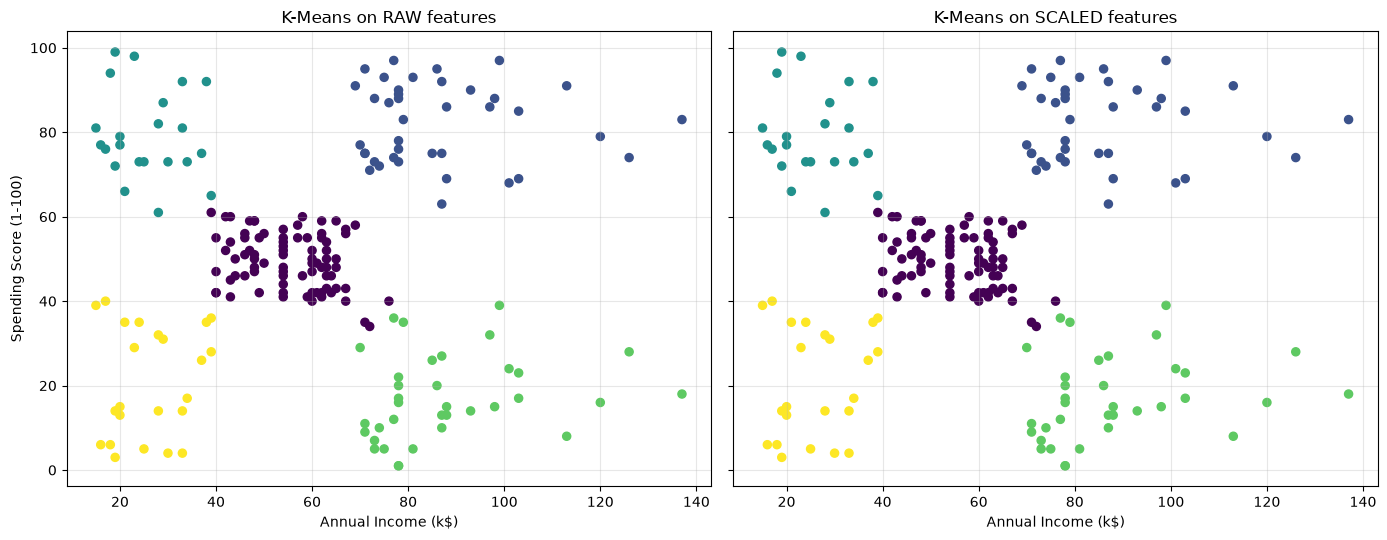

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
ax[0].scatter(X[INCOME], X[SPEND], c=labels_raw, cmap='viridis', s=34)
ax[0].set_title('K-Means on RAW features')
ax[1].scatter(X[INCOME], X[SPEND], c=labels_scaled, cmap='viridis', s=34)
ax[1].set_title('K-Means on SCALED features')
for a in ax:
    a.set_xlabel(INCOME)
    a.grid(alpha=0.3)
ax[0].set_ylabel(SPEND)
plt.tight_layout()
plt.show()

### Answer 2.2 — what the unscaled version segmented on

**It segmented on exactly the same thing as the scaled version. The two partitions are
identical: ARI = 1.000.** The five clusters have the same members, the same income ranges
and the same spending ranges; only the arbitrary cluster *numbers* differ.

The reason is Part 1.3. Scaling divides each feature by its own standard deviation, and
here those two standard deviations are 26.26 and 25.82 — within 2% of each other. The
transformation is therefore almost exactly "divide both columns by 26", which is a uniform
rescaling of the plane. Euclidean distance is unchanged up to a constant factor, every
point keeps the same nearest centroid, and K-Means lands in the same place.

**This is a negative result, and it is the honest one.** The lecture's worked template in
section 4.1 produced four income brackets because its spread ratio was 1,404x. Ours is
1.02x. The mechanism the lecture describes is real; the conditions for it are absent here.

**Keep the scaler anyway**, for two reasons that cost nothing:

1. It is a property of *this* dataset's units, not of the method. Add `Age`
   (sd 13.97, about half the others) or switch income to raw dollars and the protection
   starts mattering immediately.
2. DBSCAN in Part 5 needs it for a different reason: `eps` is an absolute distance, and a
   sensible `eps` is far easier to reason about on standardised axes.

# Part 3: Choosing K

## 3.1 The elbow

In [7]:
k_range = range(1, 11)
wcss = []
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

rows = []
for i, (k, v) in enumerate(zip(k_range, wcss)):
    imp = np.nan if i == 0 else 100 * (wcss[i - 1] - v) / wcss[i - 1]
    rows.append({'K': k, 'WCSS': round(v, 2), 'improvement %': round(imp, 1) if i else None})
elbow_tbl = pd.DataFrame(rows).set_index('K')
print(elbow_tbl.to_string())

      WCSS  improvement %
K                        
1   400.00            NaN
2   269.69           32.6
3   157.70           41.5
4   108.92           30.9
5    65.57           39.8
6    55.06           16.0
7    44.86           18.5
8    37.23           17.0
9    32.39           13.0
10   29.98            7.4


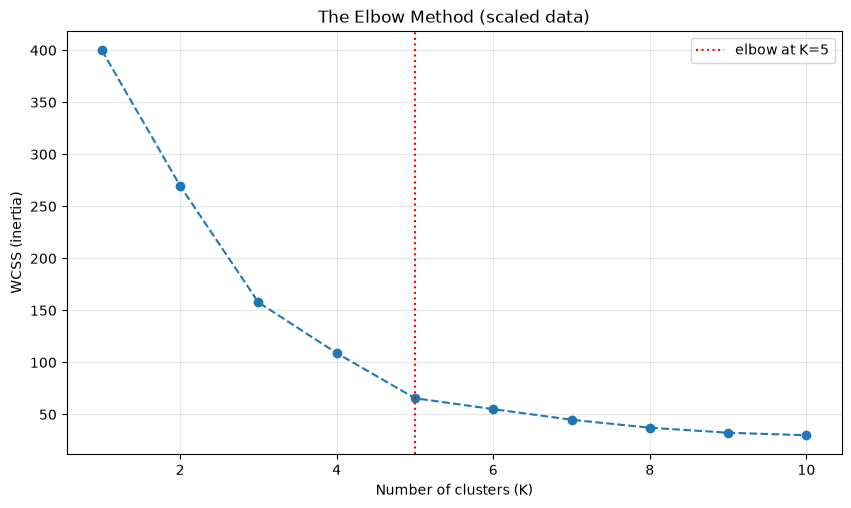

In [8]:
plt.figure(figsize=(10, 5.5))
plt.plot(list(k_range), wcss, marker='o', linestyle='--')
plt.axvline(5, color='red', ls=':', label='elbow at K=5')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS (inertia)')
plt.title('The Elbow Method (scaled data)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 3.2 The silhouette

In [9]:
sil_range = range(2, 11)
sil = []
for k in sil_range:
    labels = KMeans(n_clusters=k, init='k-means++', n_init=10,
                    random_state=RANDOM_STATE).fit_predict(X_scaled)
    sil.append(silhouette_score(X_scaled, labels))

best_k = list(sil_range)[int(np.argmax(sil))]
for k, s in zip(sil_range, sil):
    print(f'  K={k:<3d} silhouette {s:.4f}' + ('   <- best' if k == best_k else ''))

  K=2   silhouette 0.3213
  K=3   silhouette 0.4666
  K=4   silhouette 0.4939
  K=5   silhouette 0.5547   <- best
  K=6   silhouette 0.5399
  K=7   silhouette 0.5281
  K=8   silhouette 0.4552
  K=9   silhouette 0.4571
  K=10  silhouette 0.4432


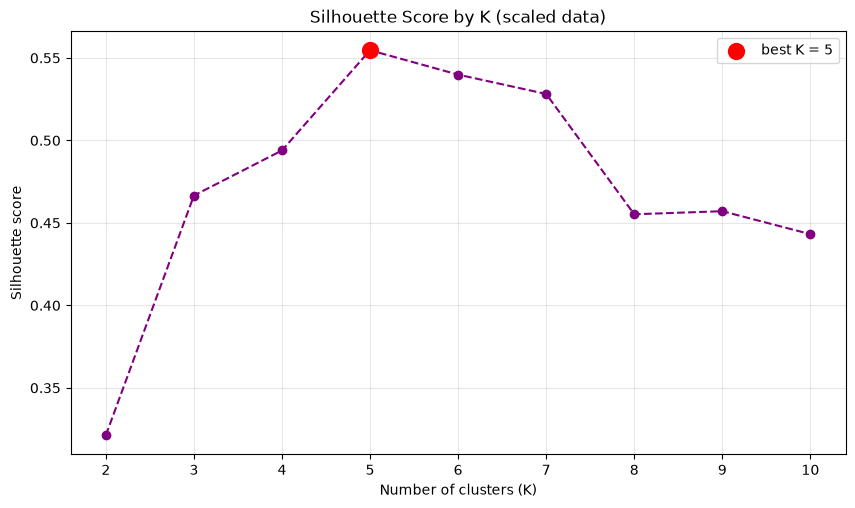

In [10]:
plt.figure(figsize=(10, 5.5))
plt.plot(list(sil_range), sil, marker='o', linestyle='--', color='purple')
plt.scatter([best_k], [max(sil)], color='red', s=130, zorder=5, label=f'best K = {best_k}')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette score')
plt.title('Silhouette Score by K (scaled data)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Part 4: Final model and strategy

In [11]:
final = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=RANDOM_STATE)
df['kmeans_cluster'] = final.fit_predict(X_scaled)

# Centroids are in scaled space; invert them so they can be plotted in real units.
scaler = StandardScaler().fit(X)
centroids = scaler.inverse_transform(final.cluster_centers_)

print('centroids in ORIGINAL units:')
print(pd.DataFrame(centroids, columns=[INCOME, SPEND]).round(1).to_string())

centroids in ORIGINAL units:
   Annual Income (k$)  Spending Score (1-100)
0                55.3                    49.5
1                86.5                    82.1
2                25.7                    79.4
3                88.2                    17.1
4                26.3                    20.9


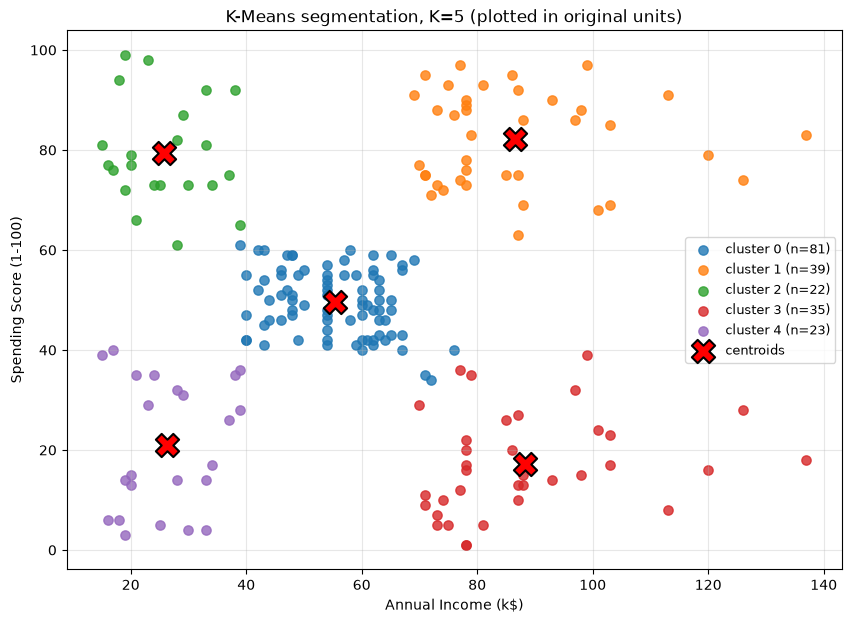

In [12]:
plt.figure(figsize=(10, 7))
for c in sorted(df.kmeans_cluster.unique()):
    m = df[df.kmeans_cluster == c]
    plt.scatter(m[INCOME], m[SPEND], s=45, alpha=0.8, label=f'cluster {c} (n={len(m)})')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=280, marker='X',
            edgecolors='black', linewidths=1.5, zorder=5, label='centroids')
plt.xlabel(INCOME)
plt.ylabel(SPEND)
plt.title('K-Means segmentation, K=5 (plotted in original units)')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

In [13]:
profile = (df.groupby('kmeans_cluster')
             .agg(n=('Age', 'size'),
                  mean_age=('Age', 'mean'),
                  mean_income=(INCOME, 'mean'),
                  mean_spend=(SPEND, 'mean'))
             .round(1))
profile['pct'] = (100 * profile['n'] / len(df)).round(1)
print(profile.to_string())

                 n  mean_age  mean_income  mean_spend   pct
kmeans_cluster                                             
0               81      42.7         55.3        49.5  40.5
1               39      32.7         86.5        82.1  19.5
2               22      25.3         25.7        79.4  11.0
3               35      41.1         88.2        17.1  17.5
4               23      45.2         26.3        20.9  11.5


# Part 5: DBSCAN

## 5.1 min_samples and the k-distance graph

5th-NN distance percentiles on scaled data:
   50th percentile: 0.207
   75th percentile: 0.334
   90th percentile: 0.468
   95th percentile: 0.600
   99th percentile: 0.925


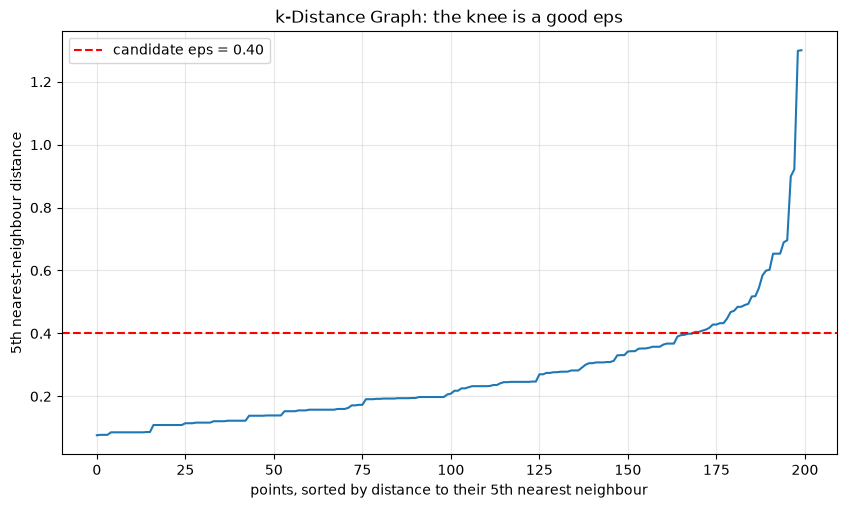

In [14]:
MIN_SAMPLES = 5           # rule of thumb: ~2 x dimensions = 4, rounded up to 5
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])

print(f'{MIN_SAMPLES}th-NN distance percentiles on scaled data:')
for p in [50, 75, 90, 95, 99]:
    print(f'  {p:>3}th percentile: {np.percentile(k_dist, p):.3f}')

plt.figure(figsize=(10, 5.5))
plt.plot(k_dist)
plt.axhline(0.40, color='red', ls='--', label='candidate eps = 0.40')
plt.xlabel(f'points, sorted by distance to their {MIN_SAMPLES}th nearest neighbour')
plt.ylabel(f'{MIN_SAMPLES}th nearest-neighbour distance')
plt.title('k-Distance Graph: the knee is a good eps')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5.2 Sweep eps

In [15]:
rows = []
for eps in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.60, 0.70, 0.80]:
    lab = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit_predict(X_scaled)
    n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
    n_noise = int((lab == -1).sum())
    # silhouette needs >= 2 clusters; compute on the non-noise points only
    if n_clusters >= 2:
        mask = lab != -1
        s = silhouette_score(X_scaled[mask], lab[mask])
    else:
        s = np.nan
    rows.append({'eps': eps, 'clusters': n_clusters, 'noise': n_noise,
                 'silhouette (excl. noise)': round(s, 3) if s == s else None})
sweep = pd.DataFrame(rows).set_index('eps')
print(sweep.to_string())

      clusters  noise  silhouette (excl. noise)
eps                                            
0.20         7     77                     0.586
0.25         6     50                     0.532
0.30         7     35                     0.524
0.35         6     23                     0.558
0.40         4     15                     0.478
0.45         3     11                     0.354
0.50         2      8                     0.388
0.60         1      5                       NaN
0.70         1      0                       NaN
0.80         1      0                       NaN


In [16]:
EPS = 0.40
db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
df['dbscan_cluster'] = db.fit_predict(X_scaled)

n_clusters_db = len(set(df.dbscan_cluster)) - (1 if -1 in set(df.dbscan_cluster) else 0)
n_noise_db = int((df.dbscan_cluster == -1).sum())
print(f'eps={EPS}, min_samples={MIN_SAMPLES}')
print(f'  clusters: {n_clusters_db}')
print(f'  noise   : {n_noise_db} of {len(df)} ({100*n_noise_db/len(df):.1f}%)')
print()
print(df.dbscan_cluster.value_counts().sort_index().to_string())

eps=0.4, min_samples=5
  clusters: 4
  noise   : 15 of 200 (7.5%)

dbscan_cluster
-1     15
 0    115
 1     11
 2     32
 3     27


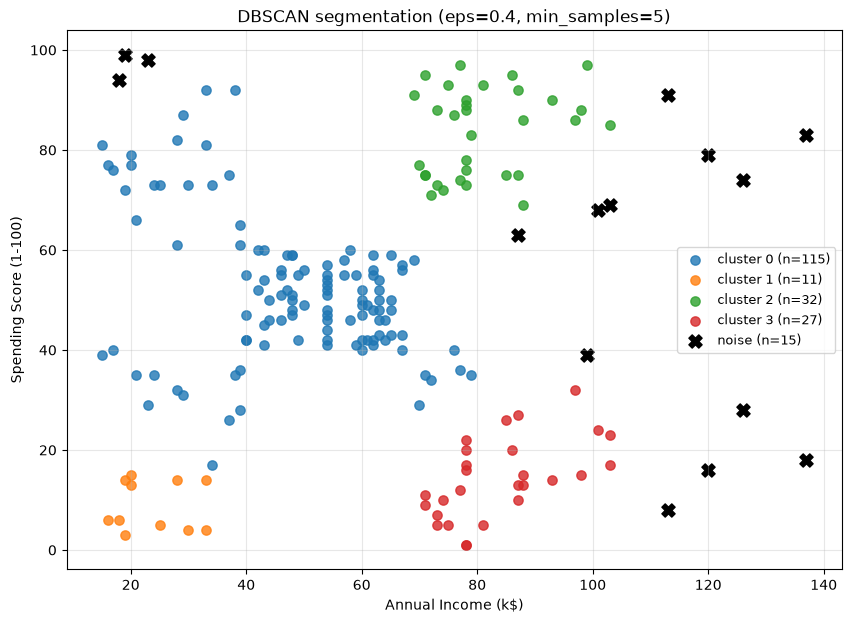

In [17]:
plt.figure(figsize=(10, 7))
noise = df.dbscan_cluster == -1
for c in sorted(df.loc[~noise, 'dbscan_cluster'].unique()):
    m = df[df.dbscan_cluster == c]
    plt.scatter(m[INCOME], m[SPEND], s=45, alpha=0.8, label=f'cluster {c} (n={len(m)})')
plt.scatter(df.loc[noise, INCOME], df.loc[noise, SPEND], c='black', s=90, marker='X',
            label=f'noise (n={int(noise.sum())})')
plt.xlabel(INCOME)
plt.ylabel(SPEND)
plt.title(f'DBSCAN segmentation (eps={EPS}, min_samples={MIN_SAMPLES})')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

In [18]:
db_profile = (df[df.dbscan_cluster != -1]
              .groupby('dbscan_cluster')
              .agg(n=('Age', 'size'), mean_age=('Age', 'mean'),
                   mean_income=(INCOME, 'mean'), mean_spend=(SPEND, 'mean'))
              .round(1))
print('DBSCAN cluster profiles (noise excluded):')
print(db_profile.to_string())
print()
print('K-Means profiles, for comparison:')
print(profile.to_string())

DBSCAN cluster profiles (noise excluded):
                  n  mean_age  mean_income  mean_spend
dbscan_cluster                                        
0               115      39.5         48.3        51.7
1                11      49.4         23.7         8.9
2                32      32.8         80.9        83.6
3                27      41.3         83.9        14.4

K-Means profiles, for comparison:
                 n  mean_age  mean_income  mean_spend   pct
kmeans_cluster                                             
0               81      42.7         55.3        49.5  40.5
1               39      32.7         86.5        82.1  19.5
2               22      25.3         25.7        79.4  11.0
3               35      41.1         88.2        17.1  17.5
4               23      45.2         26.3        20.9  11.5


## 5.3 Who did DBSCAN call noise?

In [19]:
noise_rows = df[df.dbscan_cluster == -1][['Genre', 'Age', INCOME, SPEND, 'kmeans_cluster']]
print(f'{len(noise_rows)} customers flagged as noise:')
print(noise_rows.sort_values(INCOME).to_string())
print()
print('their K-Means assignment, for comparison:')
print(noise_rows.kmeans_cluster.value_counts().sort_index().to_string())

15 customers flagged as noise:
      Genre  Age  Annual Income (k$)  Spending Score (1-100)  kmeans_cluster
7    Female   23                  18                      94               2
11   Female   35                  19                      99               2
19   Female   35                  23                      98               2
169    Male   32                  87                      63               1
184  Female   41                  99                      39               3
187    Male   28                 101                      68               1
191  Female   32                 103                      69               1
192    Male   33                 113                       8               3
193  Female   38                 113                      91               1
194  Female   47                 120                      16               3
195  Female   35                 120                      79               1
196  Female   45                 126         

### Answer 3 — do the two methods agree?

**Yes, both point to K = 5, and I am taking that forward.**

**The elbow, read from the improvement column rather than by eye:**

| K | WCSS | improvement |
|---|---|---|
| 2 | 269.69 | 32.6% |
| 3 | 157.70 | 41.5% |
| 4 | 108.92 | 30.9% |
| **5** | **65.57** | **39.8%** |
| 6 | 55.06 | **16.0%** |
| 7 | 44.86 | 18.5% |
| 10 | 29.98 | 7.4% |

Every cluster up to the fifth removes **31-42%** of the remaining WCSS. The sixth removes
**16%**, and nothing after it recovers. The drop from 39.8% to 16.0% is the elbow, and it is
a factor of 2.5 — this is about as unambiguous as an elbow ever gets.

Worth noting the improvements are **not monotonic** (K=3 buys 41.5%, more than K=2's 32.6%).
That is normal and is one reason the elbow is read as "where it falls off a cliff" rather
than "where the improvement first drops".

**The silhouette peaks at K = 5 with 0.5547**, ahead of K=6 (0.5399) and K=4 (0.4939).

**Both criteria independently choose 5.** That agreement is the useful part. When the elbow
and the silhouette disagree, the disagreement itself is information — it usually means the
cluster structure is weak and no K is clearly right. Here they coincide, and the scatter plot
shows five visually obvious groups, so three independent signals agree.

One caveat carried from the lecture: **a silhouette score is always computable, even on
structureless data.** It ranks candidate values of K; it does not prove clusters exist. Here
the plot confirms they do.

### Answer 4 — the five segments

| Cluster | Name | n (%) | Mean age | Mean income (k$) | Mean spend |
|---|---|---|---|---|---|
| 0 | **The Mainstream** | 81 (40.5%) | 42.7 | 55.3 | 49.5 |
| 1 | **Premium Loyalists** | 39 (19.5%) | 32.7 | 86.5 | 82.1 |
| 2 | **Young Aspirationals** | 22 (11.0%) | 25.3 | 25.7 | 79.4 |
| 3 | **Untapped Affluent** | 35 (17.5%) | 41.1 | 88.2 | 17.1 |
| 4 | **Cautious Budgeters** | 23 (11.5%) | 45.2 | 26.3 | 20.9 |

**Cluster 0 — The Mainstream.** Average on everything: middling income, middling spend,
the broadest age range, and **two in five customers**. This is the shop's bread and butter
and it is deliberately unexciting. *Action:* do not run a special campaign at it — at 40% of
the base, anything targeted here is effectively untargeted. Use it as the control group
against which the other four segments' campaigns are measured.

**Cluster 1 — Premium Loyalists.** High income (86.5k) and high spend (82.1), average age
32.7 — the youngest high earners. One customer in five, and almost certainly the majority of
revenue. *Action:* loyalty tier, early access to new ranges, personal shopping. The goal is
retention, not acquisition; losing one of these costs several Mainstream customers.

**Cluster 2 — Young Aspirationals.** The most interesting segment. Lowest income (25.7k)
but the second-highest spend (79.4), and by far the youngest at **25.3**. They spend a large
share of what they have. *Action:* instalment payment options, student offers, social and
influencer channels. Their income will rise with age — acquiring them cheaply now is a bet
on them becoming Cluster 1 in a decade.

**Cluster 3 — Untapped Affluent.** The highest income in the dataset (88.2k) and the lowest
spend (17.1). 35 customers who can afford to buy and do not. *Action:* this is where the
upside is, and it needs research before spend. They may shop elsewhere, may visit rarely, or
may not find the range relevant. A survey or a test campaign beats guessing. If even a third
of them moved to Cluster 1's spending level it would exceed anything available from the
Mainstream.

**Cluster 4 — Cautious Budgeters.** Low income (26.3k), low spend (20.9), oldest group at
45.2. *Action:* the lowest-priority segment commercially. Serve them well on value lines and
promotions, but do not spend acquisition budget here. Honest segmentation includes deciding
where *not* to invest.

**The structure to notice:** income and spending are close to independent. All four
combinations of high/low exist, plus a large middle. If spending simply followed income
there would be no Cluster 2 and no Cluster 3 — and those two are precisely where the
actionable decisions are.

### Answer 5 — DBSCAN

**min_samples = 5.** The rule of thumb is about 2 x dimensions; with 2 features that gives
4, and 5 is the conventional round-up. It also makes the k-distance graph slightly smoother.

**eps = 0.40**, chosen from the k-distance graph and confirmed by the sweep. The curve's knee
sits between the 75th and 90th percentile of the 5th-NN distance (0.334 and 0.468), and 0.40
falls in that band.

| eps | clusters | noise | silhouette (excl. noise) |
|---|---|---|---|
| 0.20 | 7 | 77 | 0.586 |
| 0.25 | 6 | 50 | 0.532 |
| 0.30 | 7 | 35 | 0.524 |
| 0.35 | 6 | 23 | 0.558 |
| **0.40** | **4** | **15** | **0.478** |
| 0.45 | 3 | 11 | 0.354 |
| 0.50 | 2 | 8 | 0.388 |
| 0.60 | 1 | 5 | — |
| 0.70 | 1 | 0 | — |

**Why 0.40 and not the highest silhouette.** `eps = 0.20` scores best (0.586) but calls
**77 of 200 customers noise** — 38% of the base unassigned is not a segmentation a marketing
team can use. The silhouette is flattering precisely because it is computed only on the
points that survived. At the other end, `eps >= 0.60` collapses everything into one cluster
and reports zero noise, which looks like success and carries no information. 0.40 is the
compromise: four interpretable clusters and 7.5% noise.

**The comparison with K-Means:**

| | K-Means | DBSCAN |
|---|---|---|
| segments | 5 | 4 + noise |
| largest | 81 (40.5%) | **115 (57.5%)** |
| unassigned | 0 | 15 |

DBSCAN's clusters 2 (income 80.9, spend 83.6) and 3 (income 83.9, spend 14.4) match
K-Means' Premium Loyalists and Untapped Affluent closely. But **its cluster 0 swallows 115
customers** — K-Means' Mainstream, the Young Aspirationals and most of the Cautious Budgeters
merged into one blob.

That is density-connectivity doing exactly what it is designed to do. Those groups are not
separated by an empty gap; they shade into one another through the middle of the plot, so
DBSCAN can walk from one to the next in steps of 0.40 and calls the whole thing one region.
K-Means separated them because it was *told* to produce five clusters and it will always
partition, gap or no gap.

**Neither is wrong. They answer different questions.** DBSCAN answers "where is the data
genuinely dense and separated?" — and the honest answer is that only the two high-income
corners stand apart. K-Means answers "if I must have five groups, where are the best cuts?"
For marketing, the second question is the one being asked.

### Answer 5.3 — who are the noise points?

**15 customers, 7.5% of the base, and they are not random.** They fall into two groups:

**Three low-income, extreme-spending customers** (incomes 18-23k, spending scores 94-99) —
the most extreme members of the Young Aspirationals, spending at the very top of the scale on
the lowest incomes in the dataset.

**Twelve high-income customers** (87-137k), split between high and low spenders. These are
the **top of the income distribution** — the dataset's richest customers, sitting in the
sparse right-hand tail where points are simply further apart.

**Is "belongs to no segment" a reasonable description?** *Statistically yes, commercially no.*

They genuinely are isolated: the income distribution thins out above 100k, so a 0.40 radius
catches fewer than 5 neighbours. DBSCAN is reporting the geometry accurately.

But look at who they are. **The richest customers in the database, including several who
spend heavily** (incomes 113-137k with spending scores 74-91). For a marketing team these are
plausibly the *single most valuable* people on the list, and the algorithm has handed them
back with no segment attached. K-Means put the same 15 into clusters 1, 2 and 3 — and for
this task that is more useful, even though it is less honest about the geometry.

**The general lesson: "noise" means low density, not low value.** In fraud detection those
two coincide and that is why DBSCAN is used there. In customer segmentation they can be
opposites, and the sparse tail is the premium tier.

# Part 6: The comparison

**Which was easier to tune?**

K-Means, clearly. It asks for one number, K, and two independent diagnostics are available
to choose it — the elbow and the silhouette — which agreed on 5 here. DBSCAN asks for
`min_samples` (easy: a rule of thumb gave 5) and `eps`, which is genuinely hard. `eps` is an
absolute distance in scaled feature space; it has no intuitive meaning, nothing in the output
warns you when it is wrong, and both failure modes look plausible — too small reports many
tight clusters and a pile of noise, too large reports one clean cluster and none. The
k-distance graph gives a starting point, but the sweep is what actually justifies the choice.

**Which produced more interpretable segments?**

K-Means, for this task and by a clear margin. Five balanced groups (11-40% of the base each),
every one nameable in a phrase a marketing manager would use, and complete coverage. DBSCAN's
four groups are dominated by a 115-customer blob that merges three behaviourally distinct
types, and it leaves 15 customers — including the highest earners — with no segment. K-Means'
willingness to impose structure is a liability when you are asking whether structure exists,
and an asset when you have already decided to run five campaigns.

**Is refusing to classify a feature or a problem?**

**For this task, a problem.** The 15 refused customers are mostly the top of the income
distribution. A segmentation that silently drops the richest customers is worse than useless
— it is quietly wrong in the most expensive direction.

**For fraud detection, the opposite, and emphatically.** There the question is "which
transactions do not look like anything else?", and "belongs to no cluster" *is* the answer
rather than a gap in it. K-Means cannot express it: it forces every outlier into a cluster,
where it also drags that centroid toward itself and corrupts the profile. Same property of
the same algorithm; its value flips entirely with the business question.

**Which would I deploy here?**

**K-Means with K = 5.** Three reasons:

1. **It fits the decision.** The team will run a fixed number of campaigns and needs every
   customer assigned to one. K-Means delivers exactly that; DBSCAN does not.
2. **The segments are defensible.** Two independent criteria chose K=5, the groups are
   visually obvious, and each has a name and an action attached.
3. **It is stable and cheap to re-run.** With `n_init=10` and a fixed `random_state` it
   reproduces, and new customers can be assigned by nearest centroid. DBSCAN has no native
   `predict` for unseen points at all — a real operational limitation that rarely comes up in
   teaching and always comes up in deployment.

**I would keep DBSCAN as a diagnostic alongside it.** Its disagreement is informative: the
fact that it merged the Mainstream, the Aspirationals and the Budgeters into one region is
evidence those three segments are **not separated by real gaps** — they are convenient cuts
through a continuum. That is worth knowing before anyone claims the five segments are
natural customer types. And its noise list is a ready-made high-net-worth prospect list,
which is useful for a completely different reason than the one it was computed for.